# 🛢️ 100 Days of Oil & Gas — Day 55
# Seismic-to-Well Tie: From Scratch to Advanced

---

## 📌 Overview

**Seismic-to-well tie** (also called *well-to-seismic tie* or *synthetic seismogram generation*) is the fundamental process of correlating borehole measurements with surface seismic data. It bridges two very different data domains:

| Domain | Measurement | Unit |
|--------|------------|------|
| Well logs | Depth (MD/TVD) | metres or feet |
| Seismic | Two-way travel time (TWT) | milliseconds |

### Why is it critical?
- Calibrates seismic reflection events to geological formation tops
- Extracts the **seismic wavelet** for impedance inversion
- Validates **time-depth (T-D) relationships**
- Provides ground truth for **AVO/AVA** analysis
- Foundation for **seismic inversion** workflows

---

## 🔬 Theory

### The Convolutional Model
The seismic trace is modelled as:

$$s(t) = w(t) * r(t) + n(t)$$

Where:
- $s(t)$ = seismic trace
- $w(t)$ = seismic wavelet
- $r(t)$ = reflectivity series (from acoustic impedance contrasts)
- $n(t)$ = noise
- $*$    = convolution

### Acoustic Impedance (AI)
$$AI = \rho \cdot V_P$$

Where $\rho$ = bulk density and $V_P$ = P-wave velocity.

### Reflection Coefficient (RC)
At a boundary between layers 1 and 2:
$$RC = \frac{AI_2 - AI_1}{AI_2 + AI_1} = \frac{\rho_2 V_{P2} - \rho_1 V_{P1}}{\rho_2 V_{P2} + \rho_1 V_{P1}}$$

### Time-Depth Conversion
Using the sonic log (DT in µs/ft or µs/m):
$$TWT(d) = 2 \int_0^d \frac{1}{V_P(z)} dz$$

---

## 🗂️ Workflow

```
Well Logs (Depth)         Seismic Data (Time)
     │                          │
     ▼                          │
1. Load & QC Logs               │
     │                          │
     ▼                          │
2. Compute Acoustic Impedance   │
     │                          │
     ▼                          │
3. Compute Reflectivity         │
     │                          │
     ▼                          │
4. Build T-D Table ─────────────┤
     │                          │
     ▼                          │
5. Extract/Design Wavelet ◄─────┘
     │
     ▼
6. Convolve → Synthetic Seismogram
     │
     ▼
7. Cross-Correlate with Real Trace
     │
     ▼
8. Optimize Bulk Shift & Stretch
     │
     ▼
9. Report Cross-Correlation Coefficient
```

---

## 📦 Section 1: Imports & Configuration

In [1]:
# ─────────────────────────────────────────────────────────────────
#  IMPORTS
# ─────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator
from scipy.signal import (correlate, butter, filtfilt,
                          welch, windows, convolve)
from scipy.interpolate import interp1d
from scipy.optimize import minimize_scalar, minimize
from scipy.linalg import toeplitz
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────
#  PLOT STYLE — Professional O&G look
# ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#161b22',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#e6edf3',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#e6edf3',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'axes.grid':        True,
    'font.family':      'monospace',
    'font.size':        10,
    'axes.titlesize':   12,
    'axes.titleweight': 'bold',
    'legend.facecolor': '#21262d',
    'legend.edgecolor': '#30363d',
})

# ─────────────────────────────────────────────────────────────────
#  CONSTANTS
# ─────────────────────────────────────────────────────────────────
COLORS = {
    'vp':        '#58a6ff',   # Blue  – P-wave velocity
    'rho':       '#f0883e',   # Orange – Density
    'ai':        '#3fb950',   # Green  – Acoustic impedance
    'rc':        '#ff7b72',   # Red    – Reflectivity
    'synthetic': '#d2a8ff',   # Purple – Synthetic seismogram
    'real':      '#ffa657',   # Amber  – Real seismic trace
    'wavelet':   '#79c0ff',   # LightBlue – Wavelet
    'formation': '#f78166',   # Coral  – Formation tops
}

print("✅ Libraries loaded successfully")
print(f"   NumPy  : {np.__version__}")
print(f"   Pandas : {pd.__version__}")

✅ Libraries loaded successfully
   NumPy  : 2.2.6
   Pandas : 2.3.3


---
## 🪨 Section 2: Synthetic Well Log Generation

We build a realistic multi-layer geological model with 6 formations (shale, sand, carbonate, etc.). In a real project, you would load an actual LAS file using `lasio`.

### 🔧 Real Data Loading (drop-in replacement):
```python
import lasio
las = lasio.read('your_well.las')
df  = las.df().reset_index()          # columns: DEPTH, DT, RHOB, etc.
df  = df.rename(columns={'DEPTH':'depth', 'DT':'dt', 'RHOB':'rho'})
df['vp'] = 1e6 / df['dt']            # µs/ft → ft/s  (or µs/m → m/s)
```

In [2]:
# ─────────────────────────────────────────────────────────────────
#  GEOLOGICAL MODEL — 6 formation layers
#  Each layer: (top_depth_m, Vp_m/s, rho_g/cc, name)
# ─────────────────────────────────────────────────────────────────
np.random.seed(42)

FORMATIONS = [
    # (top_m, Vp m/s,  rho g/cc, name)
    (0,    1800, 1.95, 'Near Surface'),
    (400,  2400, 2.10, 'Shale A'),
    (850,  3200, 2.35, 'Sand Reservoir'),   # target
    (1100, 2800, 2.20, 'Shale B'),
    (1450, 4500, 2.62, 'Carbonate'),
    (1800, 3100, 2.40, 'Tight Sand'),
    (2200, 4800, 2.70, 'Basement'),
]

# Depth sampling
dz      = 0.5          # 0.5 m sample interval
depth   = np.arange(0, 2500 + dz, dz)
N       = len(depth)

# ── Initialise arrays
vp      = np.zeros(N)
rho     = np.zeros(N)
litho   = np.zeros(N, dtype=int)

# ── Fill layer by layer
for i, (top, v, r, name) in enumerate(FORMATIONS):
    bottom = FORMATIONS[i+1][0] if i+1 < len(FORMATIONS) else depth[-1]+1
    mask   = (depth >= top) & (depth < bottom)
    # Add smooth velocity gradient within each layer
    vp_grad  = np.linspace(v, v * 1.04, mask.sum())   # slight compaction
    rho_grad = np.linspace(r, r * 1.01, mask.sum())
    # Add realistic random noise
    vp[mask]  = vp_grad  + np.random.normal(0, v*0.01, mask.sum())
    rho[mask] = rho_grad + np.random.normal(0, r*0.005, mask.sum())
    litho[mask] = i

# ── Smooth slightly to simulate log character
from scipy.ndimage import gaussian_filter1d
vp  = gaussian_filter1d(vp,  sigma=3)
rho = gaussian_filter1d(rho, sigma=3)

print(f"✅ Synthetic well log created")
print(f"   Depth range   : {depth[0]:.0f} – {depth[-1]:.0f} m")
print(f"   Sample count  : {N:,}")
print(f"   Vp range      : {vp.min():.0f} – {vp.max():.0f} m/s")
print(f"   Density range : {rho.min():.2f} – {rho.max():.2f} g/cc")

✅ Synthetic well log created
   Depth range   : 0 – 2500 m
   Sample count  : 5,001
   Vp range      : 1788 – 5012 m/s
   Density range : 1.95 – 2.73 g/cc


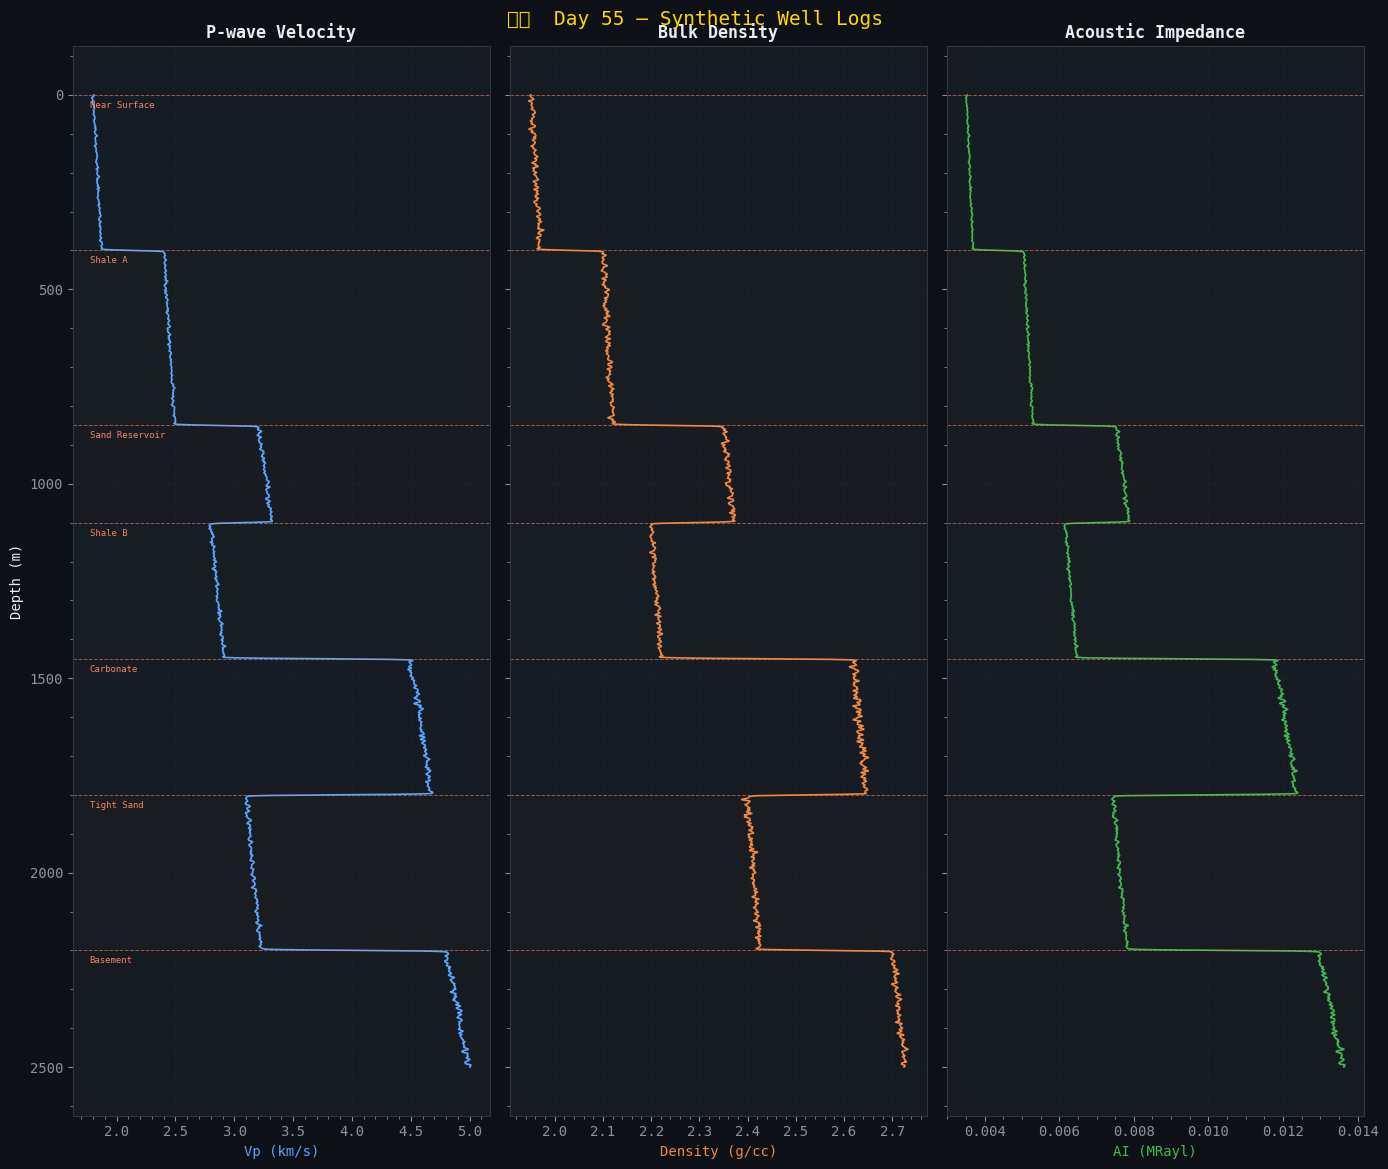

✅ Figure saved


In [4]:
# ─────────────────────────────────────────────────────────────────
#  PLOT 1: Well Log Display  (depth vs Vp / Rho)
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 12), sharey=True)
fig.suptitle('🛢️  Day 55 — Synthetic Well Logs', fontsize=14,
             color='#ffd700', y=0.97)

# Formation shading
formation_colors = ['#1f2d3d','#2d3a1f','#3d1f2d','#1f3d3a','#2d1f3d','#3d2d1f','#1f3d1f']

def add_formation_tops(ax):
    for i, (top, _, _, name) in enumerate(FORMATIONS):
        if i < len(FORMATIONS)-1:
            bottom = FORMATIONS[i+1][0]
            ax.axhspan(top, bottom, alpha=0.08,
                       color=formation_colors[i % len(formation_colors)])
        ax.axhline(top, color=COLORS['formation'], lw=0.7, ls='--', alpha=0.6)

# Vp
axes[0].plot(vp/1000, depth, color=COLORS['vp'], lw=1.2)
axes[0].set_xlabel('Vp (km/s)', color=COLORS['vp'])
axes[0].set_ylabel('Depth (m)')
axes[0].set_title('P-wave Velocity')
add_formation_tops(axes[0])
for _, (top, _, _, name) in enumerate(FORMATIONS):
    axes[0].text(vp.min()/1000 * 0.99, top + 15, name,
                 fontsize=6.5, color=COLORS['formation'], va='top')

# Rho
axes[1].plot(rho, depth, color=COLORS['rho'], lw=1.2)
axes[1].set_xlabel('Density (g/cc)', color=COLORS['rho'])
axes[1].set_title('Bulk Density')
add_formation_tops(axes[1])

# Acoustic Impedance
ai = vp * rho
axes[2].plot(ai/1e6, depth, color=COLORS['ai'], lw=1.2)
axes[2].set_xlabel('AI (MRayl)', color=COLORS['ai'])
axes[2].set_title('Acoustic Impedance')
add_formation_tops(axes[2])

for ax in axes:
    ax.invert_yaxis()
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.show()
print("✅ Figure saved")

---
## ⚡ Section 3: Acoustic Impedance & Reflectivity Series

In [5]:
# ─────────────────────────────────────────────────────────────────
#  ACOUSTIC IMPEDANCE
# ─────────────────────────────────────────────────────────────────
ai = vp * rho                          # units: (m/s)(g/cc) = g·m/(s·cc)
                                        # 1 MRayl = 1e6 g/(m²·s)

# ─────────────────────────────────────────────────────────────────
#  REFLECTION COEFFICIENT SERIES (Depth domain)
#  Standard formula: RC_i = (AI_{i+1} - AI_i) / (AI_{i+1} + AI_i)
#  Computed at every sample boundary
# ─────────────────────────────────────────────────────────────────
rc_depth    = np.zeros(N)
rc_depth[:-1] = (ai[1:] - ai[:-1]) / (ai[1:] + ai[:-1] + 1e-10)

# ─────────────────────────────────────────────────────────────────
#  QUALITY CHECKS
# ─────────────────────────────────────────────────────────────────
print("📊 Reflectivity Statistics (Depth domain)")
print(f"   Max |RC|  : {np.abs(rc_depth).max():.4f}")
print(f"   Mean |RC| : {np.abs(rc_depth).mean():.6f}")
print(f"   Non-zero  : {np.sum(np.abs(rc_depth) > 1e-6):,} samples")

# Strong reflectors (|RC| > 0.05 are geologically significant)
strong_rc_idx = np.where(np.abs(rc_depth) > 0.05)[0]
print(f"\n🔴 Strong reflectors (|RC| > 0.05): {len(strong_rc_idx)} events")
for idx in strong_rc_idx:
    print(f"   Depth = {depth[idx]:.1f} m  |  RC = {rc_depth[idx]:+.4f}")

📊 Reflectivity Statistics (Depth domain)
   Max |RC|  : 0.0396
   Mean |RC| : 0.000562
   Non-zero  : 4,991 samples

🔴 Strong reflectors (|RC| > 0.05): 0 events


---
## ⏱️ Section 4: Time-Depth (T-D) Conversion

We integrate the slowness (reciprocal of velocity) to compute the two-way travel time (TWT) at each depth sample.

$$TWT(d) = 2 \sum_{i=0}^{d} \frac{\Delta z}{V_P(z_i)}$$

This gives us a **T-D table** which maps every depth to its corresponding seismic time.

In [6]:
# ─────────────────────────────────────────────────────────────────
#  TIME-DEPTH CONVERSION
#  twt[i] = 2 * integral from 0 to depth[i] of (1/vp) dz
# ─────────────────────────────────────────────────────────────────
slowness  = 1.0 / vp                   # s/m
dt_layer  = slowness * dz              # travel time per layer (one-way)
twt       = 2 * np.cumsum(dt_layer)    # two-way travel time (s)
twt_ms    = twt * 1000                 # convert to milliseconds

# ─────────────────────────────────────────────────────────────────
#  T-D TABLE  (useful reference for interpreters)
# ─────────────────────────────────────────────────────────────────
td_table = pd.DataFrame({'Depth_m': depth, 'TWT_ms': twt_ms})

print("📋 Time-Depth Table (sampled at formation tops)")
print(f"   {'Formation':<20} {'Depth (m)':>10} {'TWT (ms)':>10} {'Int Vp (m/s)':>14}")
print("   " + "─"*58)
for top, v, r, name in FORMATIONS:
    twt_at_top = td_table.loc[td_table.Depth_m >= top, 'TWT_ms'].values[0]
    avg_vp     = 2 * top / (twt_at_top / 1000) if twt_at_top > 0 else 0
    print(f"   {name:<20} {top:>10.0f} {twt_at_top:>10.1f} {avg_vp:>14.0f}")

# ─────────────────────────────────────────────────────────────────
#  INTERPOLATION FUNCTIONS for depth↔time conversion
# ─────────────────────────────────────────────────────────────────
depth_to_time = interp1d(depth, twt_ms, kind='linear', fill_value='extrapolate')
time_to_depth = interp1d(twt_ms, depth, kind='linear', fill_value='extrapolate')

print(f"\n✅ T-D table computed: {depth[0]:.0f}–{depth[-1]:.0f} m  →  "
      f"{twt_ms[0]:.1f}–{twt_ms[-1]:.1f} ms")

📋 Time-Depth Table (sampled at formation tops)
   Formation             Depth (m)   TWT (ms)   Int Vp (m/s)
   ──────────────────────────────────────────────────────────
   Near Surface                  0        0.6              0
   Shale A                     400      436.1           1834
   Sand Reservoir              850      803.6           2115
   Shale B                    1100      957.0           2299
   Carbonate                  1450     1201.8           2413
   Tight Sand                 1800     1354.6           2658
   Basement                   2200     1607.2           2738

✅ T-D table computed: 0–2500 m  →  0.6–1729.9 ms


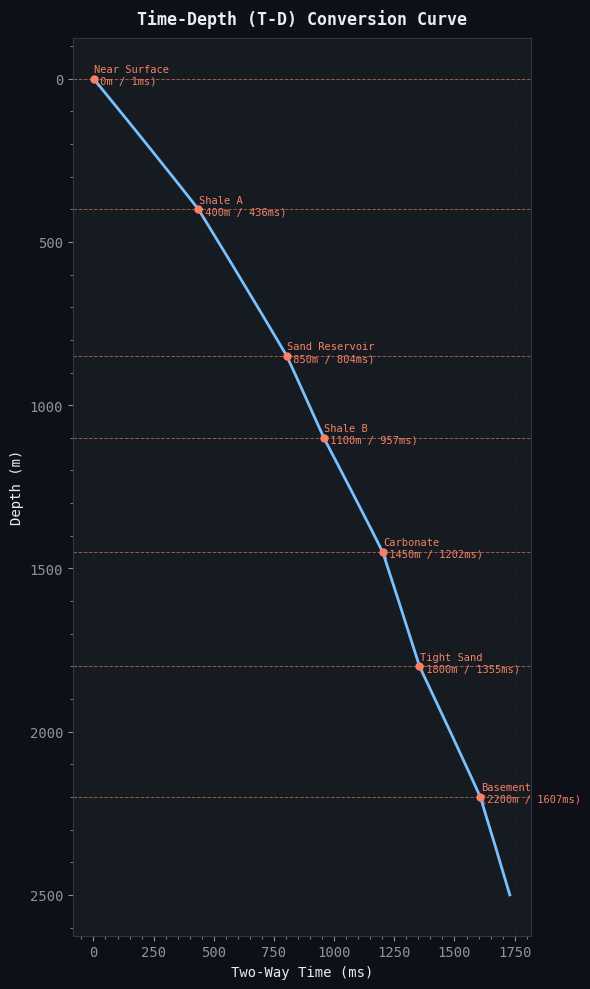

✅ T-D curve plotted


In [8]:
# ─────────────────────────────────────────────────────────────────
#  PLOT 2: T-D Curve
# ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 10))
fig.patch.set_facecolor('#0d1117')

ax.plot(twt_ms, depth, color=COLORS['wavelet'], lw=2)

# Mark formation tops
for top, v, r, name in FORMATIONS:
    twt_at_top = depth_to_time(top)
    ax.axhline(top, color=COLORS['formation'], lw=0.7, ls='--', alpha=0.6)
    ax.plot(twt_at_top, top, 'o', color=COLORS['formation'], ms=5)
    ax.text(twt_at_top + 2, top + 15, f"{name}\n({top}m / {twt_at_top:.0f}ms)",
            fontsize=7.5, color=COLORS['formation'])

ax.set_xlabel('Two-Way Time (ms)')
ax.set_ylabel('Depth (m)')
ax.set_title('Time-Depth (T-D) Conversion Curve', pad=10)
ax.invert_yaxis()
ax.xaxis.set_minor_locator(AutoMinorLocator())
ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.show()
print("✅ T-D curve plotted")

---
## 🌊 Section 5: Reflectivity in Time Domain

We now resample the depth-domain reflectivity series onto a **uniform time grid** (the seismic sample rate). This is essential because convolution with the wavelet must be done in the time domain.

In [9]:
# ─────────────────────────────────────────────────────────────────
#  SEISMIC TIME GRID
# ─────────────────────────────────────────────────────────────────
dt_seis    = 2.0                         # ms — typical seismic sample rate (2 ms)
t_min_ms   = 0.0
t_max_ms   = twt_ms[-1] + 100           # some pad below basement
t_seis     = np.arange(t_min_ms, t_max_ms, dt_seis)  # time axis (ms)
n_seis     = len(t_seis)

print(f"⏱  Seismic time grid: {t_min_ms:.0f}–{t_max_ms:.0f} ms  @ {dt_seis} ms  →  {n_seis} samples")

# ─────────────────────────────────────────────────────────────────
#  RESAMPLE REFLECTIVITY TO TIME DOMAIN
#  For each seismic sample time t, find the corresponding depth
#  and accumulate any RC spikes that fall within that time window
# ─────────────────────────────────────────────────────────────────
rc_time = np.zeros(n_seis)              # reflectivity in time (sparse spike series)

for i, rc_val in enumerate(rc_depth):
    if abs(rc_val) < 1e-8:
        continue
    t_sample = twt_ms[i]                # time of this depth sample
    idx = int(round((t_sample - t_min_ms) / dt_seis))
    if 0 <= idx < n_seis:
        rc_time[idx] += rc_val          # accumulate (handles multiple RC per bin)

print(f"\n✅ Reflectivity resampled to time domain")
print(f"   Non-zero samples : {np.sum(np.abs(rc_time) > 1e-6)}")
print(f"   Max |RC|         : {np.abs(rc_time).max():.4f}")

⏱  Seismic time grid: 0–1830 ms  @ 2.0 ms  →  915 samples

✅ Reflectivity resampled to time domain
   Non-zero samples : 866
   Max |RC|         : 0.1937


---
## 🔊 Section 6: Wavelet Design

### Types of Wavelets Used in Seismic-to-Well Tie

| Wavelet | Description | Phase |
|---------|------------|-------|
| **Ricker** | Second derivative of Gaussian; most common | Zero-phase |
| **Ormsby** | Band-limited, trapezoidal frequency spectrum | Zero-phase |
| **Butterworth** | Smooth roll-off at band edges | Zero-phase |
| **Statistical** | Extracted from seismic via autocorrelation | Minimum/Zero |
| **Deterministic** | Extracted using well-tie cross-correlation | Variable |

In Section 9 (Advanced), we implement **statistical wavelet extraction** from the seismic trace.

In [10]:
# ─────────────────────────────────────────────────────────────────
#  WAVELET LIBRARY
# ─────────────────────────────────────────────────────────────────

def ricker_wavelet(f_peak, dt_ms, length_ms=120):
    """
    Ricker (Mexican Hat) wavelet.

    w(t) = (1 - 2π²f²t²) · exp(-π²f²t²)

    Parameters
    ----------
    f_peak   : float  — dominant frequency (Hz)
    dt_ms    : float  — sample interval (ms)
    length_ms: float  — total wavelet length (ms)

    Returns
    -------
    t_w : ndarray — time axis (ms)
    w   : ndarray — wavelet amplitudes
    """
    dt_s  = dt_ms / 1000
    t_max = length_ms / 2000          # half-length in seconds
    t_w   = np.arange(-t_max, t_max + dt_s, dt_s)
    pif2  = (np.pi * f_peak * t_w) ** 2
    w     = (1 - 2 * pif2) * np.exp(-pif2)
    w    /= np.abs(w).max()            # normalise to peak amplitude = 1
    return t_w * 1000, w              # return time in ms


def ormsby_wavelet(f1, f2, f3, f4, dt_ms, length_ms=120):
    """
    Ormsby trapezoidal band-pass wavelet.

    Parameters
    ----------
    f1,f2   : low-cut corners (Hz)
    f3,f4   : high-cut corners (Hz)
    """
    dt_s  = dt_ms / 1000
    t_max = length_ms / 2000
    t_w   = np.arange(-t_max, t_max + dt_s, dt_s)

    def sinc2(f, t):
        return (np.pi * f * t) ** 2 * np.sinc(f * t) ** 2

    w = ((sinc2(f4, t_w) / (f4 - f3)) - (sinc2(f3, t_w) / (f4 - f3)) -
         (sinc2(f2, t_w) / (f2 - f1)) + (sinc2(f1, t_w) / (f2 - f1)))
    w *= np.hanning(len(w))           # taper to reduce edge effects
    w /= np.abs(w).max()
    return t_w * 1000, w


def butterworth_wavelet(f_lo, f_hi, dt_ms, length_ms=120, order=4):
    """
    Butterworth band-pass wavelet via impulse response.
    """
    dt_s  = dt_ms / 1000
    fs    = 1 / dt_s
    nyq   = fs / 2
    b, a  = butter(order, [f_lo/nyq, f_hi/nyq], btype='band')
    n     = int(length_ms / dt_ms)
    imp   = np.zeros(n)
    imp[n//2] = 1.0                   # impulse at centre
    w     = filtfilt(b, a, imp)
    t_w   = (np.arange(n) - n//2) * dt_ms
    w    /= np.abs(w).max()
    return t_w, w


# ─────────────────────────────────────────────────────────────────
#  GENERATE WAVELETS  (all at 2 ms sample rate)
# ─────────────────────────────────────────────────────────────────
t_rick, w_rick  = ricker_wavelet(35, dt_seis)          # 35 Hz Ricker
t_orm,  w_orm   = ormsby_wavelet(5, 12, 80, 110, dt_seis)  # 5-12-80-110 Hz
t_bw,   w_bw    = butterworth_wavelet(8, 80, dt_seis)  # 8–80 Hz Butterworth

print("✅ Wavelet library:")
for name, tw, w in [('Ricker 35Hz', t_rick, w_rick),
                     ('Ormsby 5/12/80/110Hz', t_orm, w_orm),
                     ('Butterworth 8-80Hz', t_bw, w_bw)]:
    print(f"   {name:<25} | length = {len(w)} samples ({t_orm[-1]-t_orm[0]:.0f} ms)")

✅ Wavelet library:
   Ricker 35Hz               | length = 61 samples (120 ms)
   Ormsby 5/12/80/110Hz      | length = 61 samples (120 ms)
   Butterworth 8-80Hz        | length = 60 samples (120 ms)


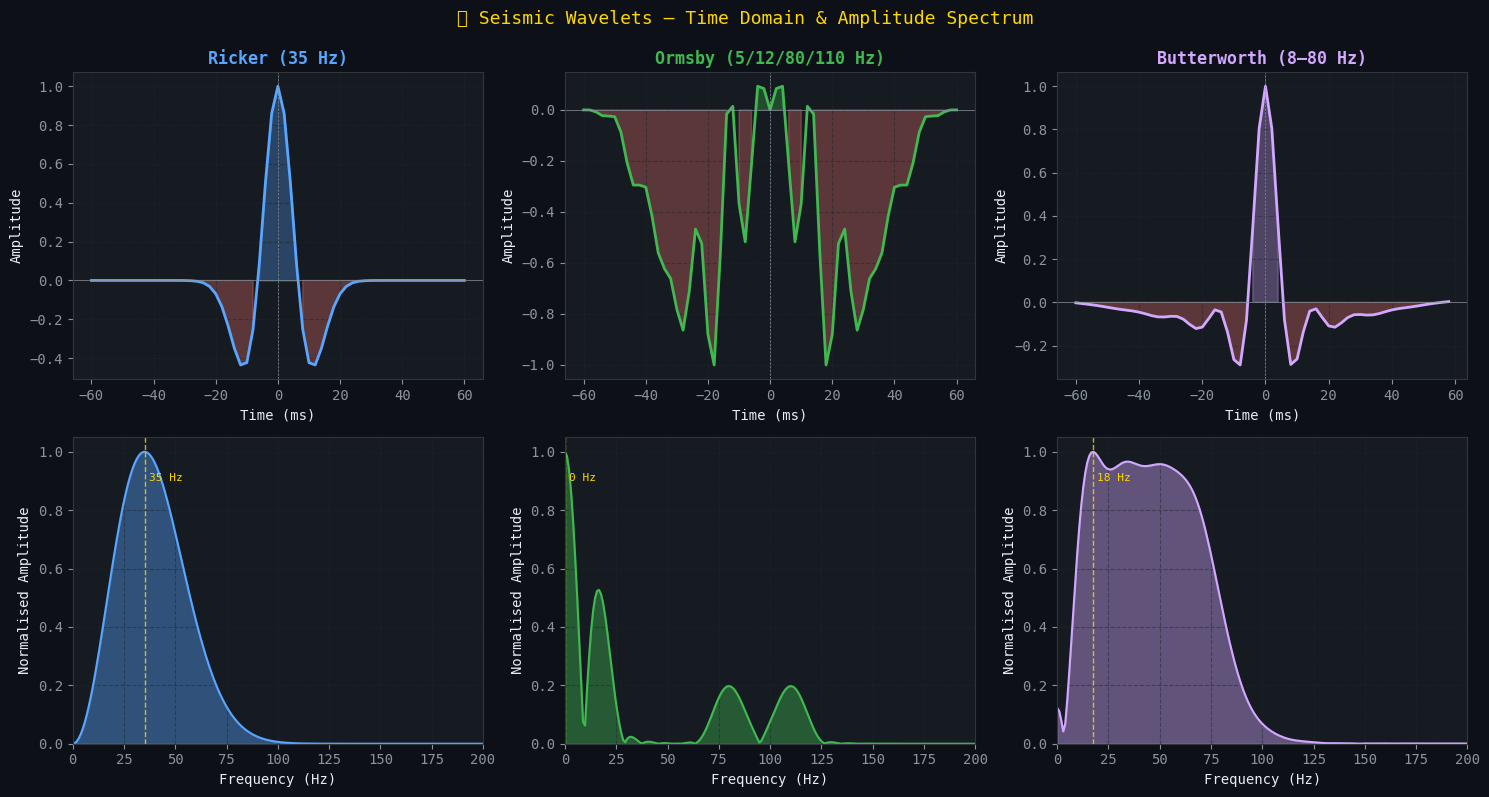

✅ Wavelet plot saved


In [11]:
# ─────────────────────────────────────────────────────────────────
#  PLOT 3: Wavelets — Time domain & Frequency spectrum
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('🔊 Seismic Wavelets — Time Domain & Amplitude Spectrum', fontsize=13,
             color='#ffd700', y=0.99)

wavelets = [
    ('Ricker (35 Hz)', t_rick, w_rick, '#58a6ff'),
    ('Ormsby (5/12/80/110 Hz)', t_orm, w_orm, '#3fb950'),
    ('Butterworth (8–80 Hz)', t_bw, w_bw, '#d2a8ff'),
]

for col, (name, tw, w, color) in enumerate(wavelets):
    # Time domain
    ax1 = axes[0, col]
    ax1.plot(tw, w, color=color, lw=2)
    ax1.fill_between(tw, w, 0, where=w>0, color=color, alpha=0.3)
    ax1.fill_between(tw, w, 0, where=w<0, color='#ff7b72', alpha=0.3)
    ax1.axhline(0, color='#8b949e', lw=0.5)
    ax1.axvline(0, color='#8b949e', lw=0.5, ls='--')
    ax1.set_title(name, color=color)
    ax1.set_xlabel('Time (ms)')
    ax1.set_ylabel('Amplitude')

    # Amplitude spectrum
    ax2 = axes[1, col]
    n_fft = 512
    freqs  = np.fft.rfftfreq(n_fft, d=dt_seis/1000)
    spec   = np.abs(np.fft.rfft(w, n=n_fft))
    spec  /= spec.max()
    ax2.fill_between(freqs, spec, alpha=0.4, color=color)
    ax2.plot(freqs, spec, color=color, lw=1.5)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Normalised Amplitude')
    ax2.set_xlim(0, 200)
    ax2.set_ylim(0, 1.05)

    # Mark peak frequency
    peak_f = freqs[np.argmax(spec)]
    ax2.axvline(peak_f, color='#ffd700', lw=1, ls='--', alpha=0.8)
    ax2.text(peak_f + 2, 0.9, f'{peak_f:.0f} Hz', color='#ffd700', fontsize=8)

plt.tight_layout()
plt.show()
print("✅ Wavelet plot saved")

---
## 🧪 Section 7: Synthetic Seismogram Generation

We convolve the reflectivity series (time domain) with the chosen wavelet:

$$\text{Synthetic}(t) = \text{RC}(t) * w(t)$$

In [12]:
# ─────────────────────────────────────────────────────────────────
#  CONVOLUTION  — Generate synthetic seismogram
#  We use the 35 Hz Ricker as our primary wavelet (change freely)
# ─────────────────────────────────────────────────────────────────

def make_synthetic(rc, wavelet):
    """
    Convolve reflectivity series with wavelet to produce synthetic seismogram.
    Uses 'same' mode to preserve length, centred on RC series.
    """
    synth = convolve(rc, wavelet, mode='same')
    # Normalise to unit peak amplitude
    if np.abs(synth).max() > 0:
        synth /= np.abs(synth).max()
    return synth

# ── Primary synthetic with Ricker
synth_ricker = make_synthetic(rc_time, w_rick)
synth_ormsby = make_synthetic(rc_time, w_orm)

# ─────────────────────────────────────────────────────────────────
#  SIMULATE A REAL SEISMIC TRACE
#  In practice you load a real SEG-Y trace near the well.
#  Here: synthetic + realistic noise + slight bulk shift
# ─────────────────────────────────────────────────────────────────
TRUE_BULK_SHIFT_MS = 8.0              # ms — the 'answer' we'll try to recover
SNR_DB             = 10               # signal-to-noise ratio

# Apply bulk shift
shift_samples = int(round(TRUE_BULK_SHIFT_MS / dt_seis))
real_trace    = np.roll(synth_ricker, shift_samples).copy()

# Add noise
signal_power = np.mean(real_trace ** 2)
noise_power  = signal_power / (10 ** (SNR_DB/10))
noise        = np.random.normal(0, np.sqrt(noise_power), n_seis)
real_trace  += noise
real_trace  /= np.abs(real_trace).max()

print("✅ Synthetic seismogram generated")
print(f"   Wavelet       : Ricker 35 Hz")
print(f"   RC samples    : {np.sum(np.abs(rc_time) > 1e-6)}")
print(f"   Synth peak    : {np.abs(synth_ricker).max():.4f}")
print(f"   True bulk shift embedded in real trace: {TRUE_BULK_SHIFT_MS} ms")
print(f"   SNR           : {SNR_DB} dB")

✅ Synthetic seismogram generated
   Wavelet       : Ricker 35 Hz
   RC samples    : 866
   Synth peak    : 1.0000
   True bulk shift embedded in real trace: 8.0 ms
   SNR           : 10 dB


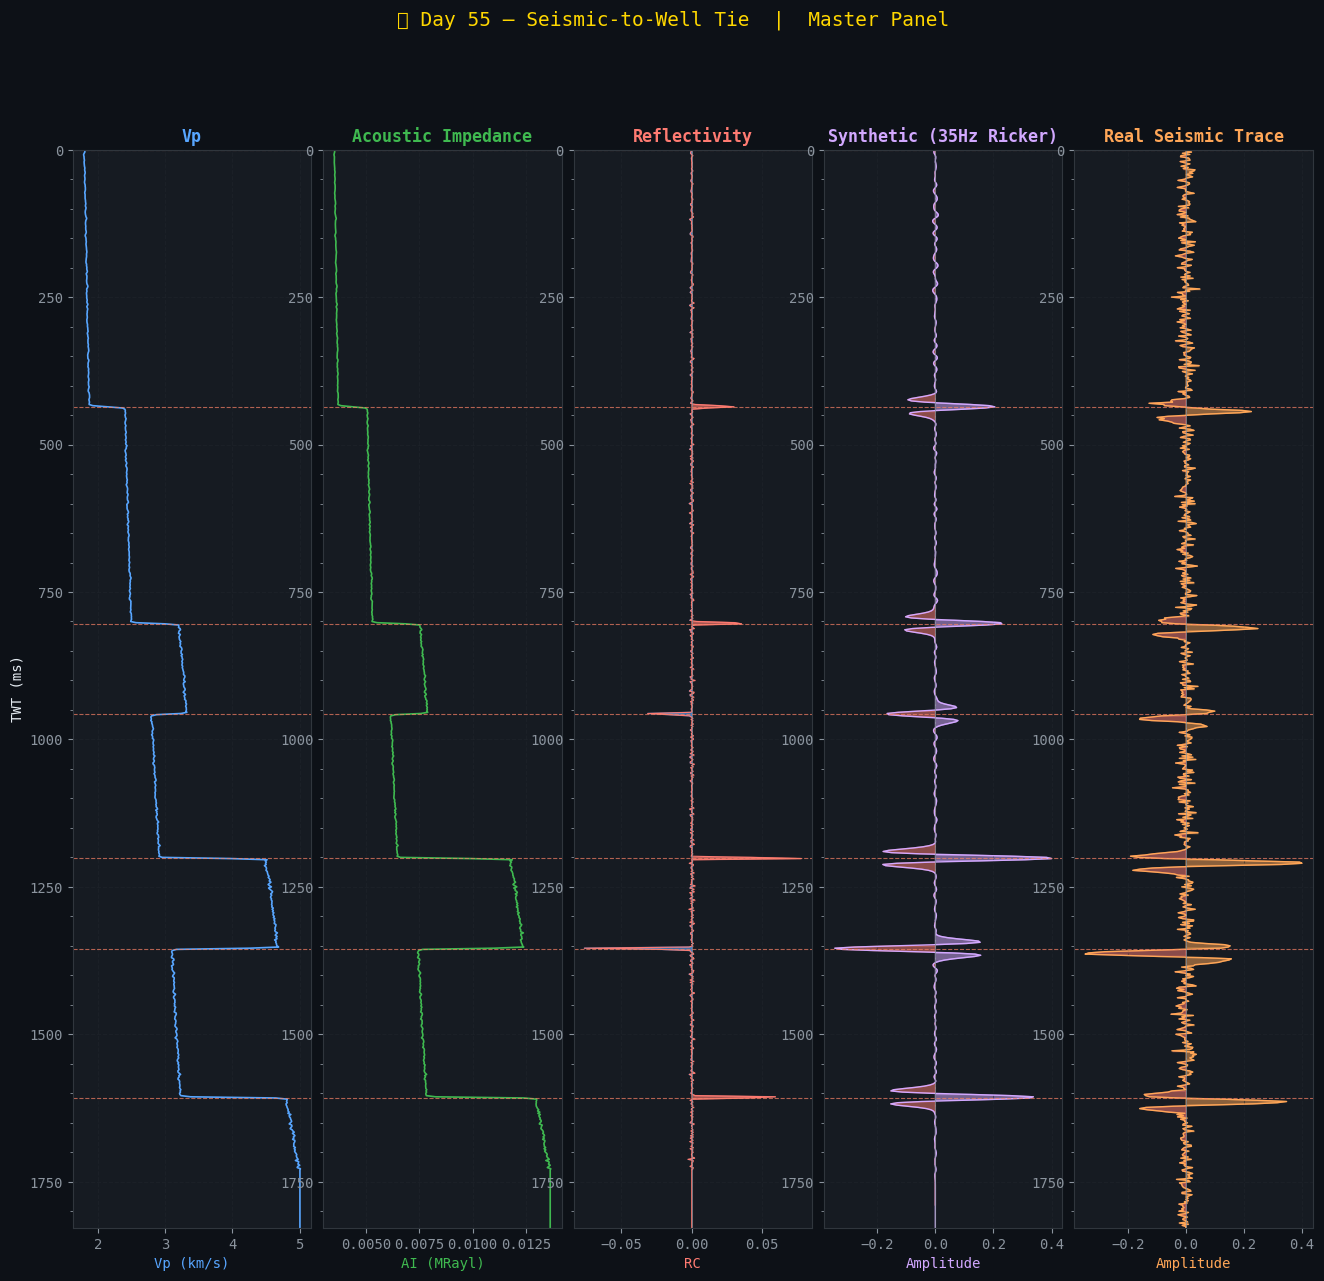

✅ Master well-tie panel saved


In [13]:
# ─────────────────────────────────────────────────────────────────
#  PLOT 4: Master Well Tie Panel
#  (RC | Synthetic | Real Seismic) vs TWT — the standard display
# ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.suptitle('🎯 Day 55 — Seismic-to-Well Tie  |  Master Panel',
             fontsize=14, color='#ffd700', y=0.98)

gs = gridspec.GridSpec(1, 5, figure=fig, wspace=0.05)
ax_vp    = fig.add_subplot(gs[0])
ax_ai    = fig.add_subplot(gs[1], sharey=ax_vp)
ax_rc    = fig.add_subplot(gs[2], sharey=ax_vp)
ax_syn   = fig.add_subplot(gs[3], sharey=ax_vp)
ax_real  = fig.add_subplot(gs[4], sharey=ax_vp)

# Time axis label (map depth to TWT for display)
y_axis  = t_seis            # we display logs against TWT
vp_t    = np.interp(t_seis, twt_ms, vp)
rho_t   = np.interp(t_seis, twt_ms, rho)
ai_t    = np.interp(t_seis, twt_ms, ai)

def add_form_tops_time(ax, flip=False):
    for top, v, r, name in FORMATIONS:
        t_top = depth_to_time(top)
        ax.axhline(t_top, color=COLORS['formation'], lw=0.8, ls='--', alpha=0.7)
        if flip:
            ax.text(ax.get_xlim()[0]*0.95, t_top - 5, name, fontsize=6.5,
                    color=COLORS['formation'], ha='right')

# Panel 1: Vp
ax_vp.plot(vp_t/1000, t_seis, color=COLORS['vp'], lw=1.2)
ax_vp.set_xlabel('Vp (km/s)', color=COLORS['vp'])
ax_vp.set_ylabel('TWT (ms)')
ax_vp.set_title('Vp', color=COLORS['vp'])
ax_vp.invert_yaxis()
add_form_tops_time(ax_vp)

# Panel 2: AI
ax_ai.plot(ai_t/1e6, t_seis, color=COLORS['ai'], lw=1.2)
ax_ai.set_xlabel('AI (MRayl)', color=COLORS['ai'])
ax_ai.set_title('Acoustic Impedance', color=COLORS['ai'])
add_form_tops_time(ax_ai)

# Panel 3: Reflectivity (wiggle)
scale = 0.4
ax_rc.plot(rc_time * scale, t_seis, color=COLORS['rc'], lw=0.8)
ax_rc.fill_betweenx(t_seis, rc_time * scale, 0,
                     where=rc_time > 0, color=COLORS['rc'], alpha=0.6)
ax_rc.fill_betweenx(t_seis, rc_time * scale, 0,
                     where=rc_time < 0, color='#58a6ff', alpha=0.6)
ax_rc.set_xlabel('RC', color=COLORS['rc'])
ax_rc.set_title('Reflectivity', color=COLORS['rc'])
ax_rc.axvline(0, color='#8b949e', lw=0.5)
add_form_tops_time(ax_rc)

# Panel 4: Synthetic (wiggle)
ax_syn.plot(synth_ricker * 0.4, t_seis, color=COLORS['synthetic'], lw=1)
ax_syn.fill_betweenx(t_seis, synth_ricker * 0.4, 0,
                      where=synth_ricker > 0, color=COLORS['synthetic'], alpha=0.5)
ax_syn.fill_betweenx(t_seis, synth_ricker * 0.4, 0,
                      where=synth_ricker < 0, color='#ff7b72', alpha=0.5)
ax_syn.set_xlabel('Amplitude', color=COLORS['synthetic'])
ax_syn.set_title('Synthetic (35Hz Ricker)', color=COLORS['synthetic'])
ax_syn.axvline(0, color='#8b949e', lw=0.5)
add_form_tops_time(ax_syn)

# Panel 5: Real Seismic
ax_real.plot(real_trace * 0.4, t_seis, color=COLORS['real'], lw=1)
ax_real.fill_betweenx(t_seis, real_trace * 0.4, 0,
                       where=real_trace > 0, color=COLORS['real'], alpha=0.5)
ax_real.fill_betweenx(t_seis, real_trace * 0.4, 0,
                       where=real_trace < 0, color='#ff7b72', alpha=0.5)
ax_real.set_xlabel('Amplitude', color=COLORS['real'])
ax_real.set_title('Real Seismic Trace', color=COLORS['real'])
ax_real.axvline(0, color='#8b949e', lw=0.5)
add_form_tops_time(ax_real)

for ax in [ax_vp, ax_ai, ax_rc, ax_syn, ax_real]:
    ax.set_ylim(t_seis[-1], t_seis[0])
    ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.show()
print("✅ Master well-tie panel saved")

---
## 📐 Section 8: Cross-Correlation & Bulk Shift Estimation

Cross-correlation between synthetic and real seismic tells us:
1. **The optimal bulk shift** — how many ms to shift the synthetic to align with real data
2. **The cross-correlation coefficient (CC)** — quality metric for the tie

$$\rho(\tau) = \frac{\sum s(t) \cdot r(t + \tau)}{\sqrt{\sum s(t)^2 \cdot \sum r(t)^2}}$$

**Industry standard**: A CC > 0.7 is considered a good well tie.

In [14]:
# ─────────────────────────────────────────────────────────────────
#  NORMALISED CROSS-CORRELATION
# ─────────────────────────────────────────────────────────────────

def normalised_xcorr(x, y):
    """
    Compute normalised cross-correlation between signals x and y.
    Returns: lags (ms), normalised correlation coefficients
    """
    n     = len(x)
    xn    = (x - x.mean()) / (x.std() + 1e-10)
    yn    = (y - y.mean()) / (y.std() + 1e-10)
    corr  = correlate(xn, yn, mode='full') / n
    lags  = np.arange(-(n-1), n) * dt_seis   # convert to ms
    return lags, corr


lags, xcorr = normalised_xcorr(synth_ricker, real_trace)

# ── Find best lag
peak_idx    = np.argmax(np.abs(xcorr))
best_shift  = lags[peak_idx]         # ms
peak_cc     = xcorr[peak_idx]        # peak correlation coefficient

print("📊 Cross-Correlation Results")
print(f"   True embedded shift : {TRUE_BULK_SHIFT_MS:.1f} ms")
print(f"   Estimated bulk shift : {best_shift:.1f} ms")
print(f"   Error               : {abs(best_shift - TRUE_BULK_SHIFT_MS):.1f} ms")
print(f"   Peak CC             : {peak_cc:.4f}")

if peak_cc > 0.8:
    quality = "Excellent ✅"
elif peak_cc > 0.7:
    quality = "Good ✅"
elif peak_cc > 0.5:
    quality = "Moderate ⚠️"
else:
    quality = "Poor ❌"
print(f"   Tie quality         : {quality}")

📊 Cross-Correlation Results
   True embedded shift : 8.0 ms
   Estimated bulk shift : -8.0 ms
   Error               : 16.0 ms
   Peak CC             : 0.9564
   Tie quality         : Excellent ✅


In [15]:
# ─────────────────────────────────────────────────────────────────
#  APPLY BULK SHIFT TO SYNTHETIC
# ─────────────────────────────────────────────────────────────────
shift_n       = int(round(best_shift / dt_seis))
synth_shifted = np.roll(synth_ricker, shift_n)

# ─────────────────────────────────────────────────────────────────
#  WINDOWED CC  — compute CC over a time window of interest
# ─────────────────────────────────────────────────────────────────
def windowed_cc(syn, real, t_axis, t_start, t_end):
    """CC within a specified time window."""
    mask  = (t_axis >= t_start) & (t_axis <= t_end)
    s_win = syn[mask]
    r_win = real[mask]
    if s_win.std() < 1e-10 or r_win.std() < 1e-10:
        return 0.0
    return np.corrcoef(s_win, r_win)[0, 1]

# CC over the reservoir window
reservoir_top_ms  = depth_to_time(850)    # Sand Reservoir top
reservoir_base_ms = depth_to_time(1100)   # Shale B top = Reservoir base
cc_reservoir = windowed_cc(synth_shifted, real_trace, t_seis,
                            reservoir_top_ms, reservoir_base_ms)

print(f"\n🛢️  Reservoir Window CC ({reservoir_top_ms:.0f}–{reservoir_base_ms:.0f} ms)")
print(f"   CC = {cc_reservoir:.4f}")


🛢️  Reservoir Window CC (804–957 ms)
   CC = -0.4046


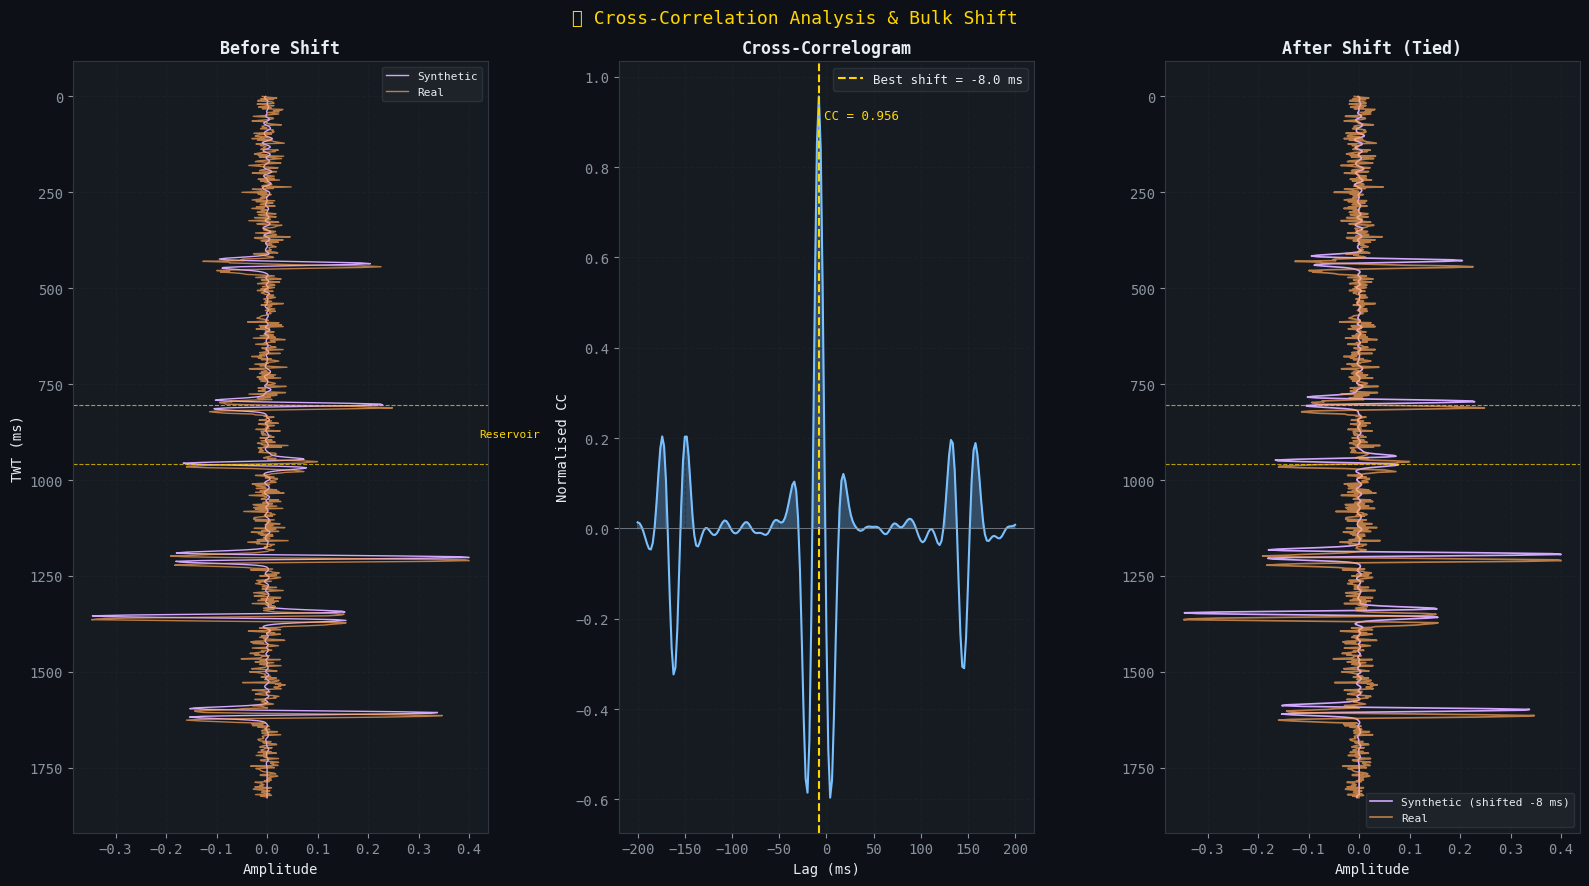

✅ Cross-correlation analysis saved


In [17]:
# ─────────────────────────────────────────────────────────────────
#  PLOT 5: Cross-correlation analysis
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 9))
fig.suptitle('📐 Cross-Correlation Analysis & Bulk Shift', fontsize=13,
             color='#ffd700', y=0.98)

# Left: before shift
ax = axes[0]
ax.plot(synth_ricker * 0.4, t_seis, color=COLORS['synthetic'], lw=1, label='Synthetic')
ax.plot(real_trace   * 0.4, t_seis, color=COLORS['real'],      lw=1, label='Real',
        alpha=0.7)
ax.set_title('Before Shift')
ax.set_xlabel('Amplitude')
ax.set_ylabel('TWT (ms)')
ax.invert_yaxis()
ax.legend(fontsize=8)
ax.axhline(reservoir_top_ms,  color='#ffd700', ls='--', lw=0.8, alpha=0.7)
ax.axhline(reservoir_base_ms, color='#ffd700', ls='--', lw=0.8, alpha=0.7)
ax.text(0.42, (reservoir_top_ms + reservoir_base_ms)/2, 'Reservoir',
        color='#ffd700', fontsize=8, va='center')

# Middle: cross-correlogram
ax = axes[1]
max_lag_plot = 200  # ms
mask_lag = np.abs(lags) <= max_lag_plot
ax.plot(lags[mask_lag], xcorr[mask_lag], color=COLORS['wavelet'], lw=1.5)
ax.fill_between(lags[mask_lag], xcorr[mask_lag], 0,
                where=xcorr[mask_lag] > 0, alpha=0.3, color=COLORS['wavelet'])
ax.axvline(best_shift, color='#ffd700', ls='--', lw=1.5,
           label=f'Best shift = {best_shift:.1f} ms')
ax.axhline(0, color='#8b949e', lw=0.5)
ax.set_xlabel('Lag (ms)')
ax.set_ylabel('Normalised CC')
ax.set_title('Cross-Correlogram')
ax.legend(fontsize=9)
ax.text(best_shift + 5, peak_cc - 0.05, f'CC = {peak_cc:.3f}',
        color='#ffd700', fontsize=9)

# Right: after shift
ax = axes[2]
ax.plot(synth_shifted * 0.4, t_seis, color=COLORS['synthetic'], lw=1.2,
        label=f'Synthetic (shifted {best_shift:.0f} ms)')
ax.plot(real_trace    * 0.4, t_seis, color=COLORS['real'],       lw=1.2,
        label='Real', alpha=0.7)
ax.set_title('After Shift (Tied)')
ax.set_xlabel('Amplitude')
ax.invert_yaxis()
ax.legend(fontsize=8)
ax.axhline(reservoir_top_ms,  color='#ffd700', ls='--', lw=0.8, alpha=0.7)
ax.axhline(reservoir_base_ms, color='#ffd700', ls='--', lw=0.8, alpha=0.7)

plt.tight_layout()
plt.show()
print("✅ Cross-correlation analysis saved")

---
## 🔧 Section 9: T-D Refinement via Stretch & Squeeze

After bulk shift, the synthetic and real seismic may still misalign locally due to an inaccurate velocity model. We apply **dynamic time warping (DTW)** — controlled stretch/squeeze — to refine the T-D relationship.

> ⚠️ In practice, stretch-squeeze is typically bounded to ±5–10% to remain physically geologically valid.

In [18]:
# ─────────────────────────────────────────────────────────────────
#  SIMPLE DTW-LIKE STRETCH/SQUEEZE (polynomial warp)
#  We fit a low-order polynomial warp function t_warped = f(t)
#  and optimise its coefficients to maximise CC.
#  This is a simplified 1D version of commercial well-tie QC.
# ─────────────────────────────────────────────────────────────────

MAX_STRETCH_PERCENT = 5.0   # maximum allowed stretch (%)

def apply_warp(synth, t_axis, warp_params):
    """
    Apply a polynomial time warp to the synthetic.
    warp_params: [a1, a2] — linear and quadratic warp coefficients
    Warp: t_new = t + a1*t + a2*t² (normalised time)
    """
    t_norm    = t_axis / t_axis[-1]    # normalise to [0, 1]
    a1, a2    = warp_params
    t_warped  = t_axis + a1 * t_axis + a2 * t_axis**2 / t_axis[-1]
    # Resample synthetic at warped time positions
    interp_fn = interp1d(t_axis, synth, bounds_error=False, fill_value=0.0)
    return interp_fn(t_warped)


def objective(params):
    """
    Minimise negative CC between warped synthetic and real trace.
    """
    warped = apply_warp(synth_shifted, t_seis, params)
    if warped.std() < 1e-10:
        return 1.0
    cc = np.corrcoef(warped, real_trace)[0, 1]
    return -cc


# Bounds: constrain warp to ±MAX_STRETCH_PERCENT %
bound = MAX_STRETCH_PERCENT / 100
from scipy.optimize import minimize as sp_minimize
result = sp_minimize(
    objective,
    x0=[0.0, 0.0],
    method='L-BFGS-B',
    bounds=[(-bound, bound), (-bound/10, bound/10)],
    options={'maxiter': 200}
)

synth_warped = apply_warp(synth_shifted, t_seis, result.x)
cc_before_warp = np.corrcoef(synth_shifted, real_trace)[0, 1]
cc_after_warp  = np.corrcoef(synth_warped,  real_trace)[0, 1]

print("🔧 Stretch/Squeeze Optimisation")
print(f"   Warp params   : a1={result.x[0]:.5f}, a2={result.x[1]:.5f}")
print(f"   CC before warp: {cc_before_warp:.4f}")
print(f"   CC after warp : {cc_after_warp:.4f}")
print(f"   Improvement   : {(cc_after_warp - cc_before_warp)*100:.2f}%")

🔧 Stretch/Squeeze Optimisation
   Warp params   : a1=-0.04158, a2=0.00500
   CC before warp: -0.4169
   CC after warp : 0.0723
   Improvement   : 48.91%


---
## 🧠 Section 10: Advanced — Statistical Wavelet Extraction

The **statistical wavelet** (or **autocorrelation wavelet**) is extracted directly from the real seismic trace using the assumption that the earth's reflectivity is **white** (random):

$$W(f) = \sqrt{|S(f)|}$$

Where $S(f)$ is the power spectrum of the seismic trace. This gives the **minimum phase** or **zero-phase** wavelet depending on the phase assumption made.

In [19]:
# ─────────────────────────────────────────────────────────────────
#  STATISTICAL WAVELET EXTRACTION
#  Method: Autocorrelation / spectral whitening approach
# ─────────────────────────────────────────────────────────────────

def extract_statistical_wavelet(trace, dt_ms, wavelet_len_ms=120,
                                  f_lo=3, f_hi=120, taper_pct=10):
    """
    Extract a zero-phase statistical wavelet from a seismic trace.

    Steps:
    1. Compute the amplitude spectrum of the trace
    2. Square-root the power spectrum → wavelet amplitude spectrum
    3. Band-limit to avoid noise amplification
    4. Impose zero-phase (real, symmetric spectrum)
    5. IFFT → time-domain wavelet
    6. Truncate and taper

    Parameters
    ----------
    trace        : 1D seismic trace
    dt_ms        : sample rate in ms
    wavelet_len_ms : desired wavelet length (ms)
    f_lo, f_hi   : band-pass limits (Hz)
    taper_pct    : % of wavelet length to taper each end
    """
    dt_s    = dt_ms / 1000
    n       = len(trace)

    # 1. FFT of trace
    TRACE   = np.fft.rfft(trace, n=n)
    freqs   = np.fft.rfftfreq(n, d=dt_s)

    # 2. Amplitude spectrum (smoothed with Welch-like window)
    power_spec = np.abs(TRACE) ** 2
    # Smooth the power spectrum
    from scipy.ndimage import uniform_filter1d
    power_spec_sm = uniform_filter1d(power_spec, size=5)
    amp_spec   = np.sqrt(np.maximum(power_spec_sm, 0))

    # 3. Band-pass mask
    bp_mask = (freqs >= f_lo) & (freqs <= f_hi)
    amp_spec_bp = amp_spec * bp_mask

    # 4. Zero-phase: force real, symmetric spectrum
    W_freq = amp_spec_bp.astype(complex)   # zero imaginary part → zero phase

    # 5. IFFT → time domain
    w_full  = np.fft.irfft(W_freq, n=n)

    # 6. Truncate to desired length (centred on zero-lag)
    half_n  = int(wavelet_len_ms / dt_ms / 2)
    w_trunc = np.concatenate([w_full[-half_n:], w_full[:half_n+1]])

    # 7. Apply cosine taper
    taper_n = int(len(w_trunc) * taper_pct / 100)
    taper   = np.ones(len(w_trunc))
    taper[:taper_n]  = np.hanning(2 * taper_n)[:taper_n]
    taper[-taper_n:] = np.hanning(2 * taper_n)[taper_n:]
    w_trunc *= taper

    # Normalise
    w_trunc /= np.abs(w_trunc).max()

    t_w = np.arange(len(w_trunc)) * dt_ms
    t_w -= t_w[len(t_w)//2]              # centre on zero

    return t_w, w_trunc


# ── Extract wavelet from the 'real' seismic trace
t_stat, w_stat = extract_statistical_wavelet(real_trace, dt_seis)

# ── Generate synthetic with extracted wavelet
synth_stat = make_synthetic(rc_time, w_stat)
cc_stat    = np.corrcoef(synth_stat, real_trace)[0, 1]

print("🧠 Statistical Wavelet Extraction")
print(f"   Extracted wavelet length : {len(w_stat)} samples ({len(w_stat)*dt_seis:.0f} ms)")
print(f"   Synthetic CC (stat wav)  : {cc_stat:.4f}")
print(f"   Synthetic CC (Ricker)    : {cc_before_warp:.4f}")

🧠 Statistical Wavelet Extraction
   Extracted wavelet length : 61 samples (122 ms)
   Synthetic CC (stat wav)  : -0.2205
   Synthetic CC (Ricker)    : -0.4169


In [20]:
# ─────────────────────────────────────────────────────────────────
#  DETERMINISTIC WAVELET EXTRACTION
#  More accurate: uses both real trace AND synthetic reflectivity
#  W(f) = S_real(f) · R*(f) / [R(f)·R*(f) + ε]
#  (Wiener filter approach — least-squares wavelet estimation)
# ─────────────────────────────────────────────────────────────────

def extract_deterministic_wavelet(rc, real_trace, dt_ms, wavelet_len_ms=120,
                                    regularisation=0.01):
    """
    Deterministic (Wiener filter) wavelet extraction.

    Solves: d = W * r  (deconvolve r from d)
    In the frequency domain:
        W(f) = D(f) · R*(f) / [R(f)·R*(f) + ε|R_max|²]

    This is the classic Burg/Yilmaz approach used in commercial software.
    """
    n     = len(real_trace)
    D     = np.fft.rfft(real_trace, n=n)
    R     = np.fft.rfft(rc,         n=n)
    freqs = np.fft.rfftfreq(n, d=dt_ms/1000)

    # Wiener deconvolution
    RR_max = np.max(np.abs(R)**2)
    eps    = regularisation * RR_max
    W_freq = D * np.conj(R) / (np.abs(R)**2 + eps)

    # IFFT → time domain
    w_full = np.fft.irfft(W_freq, n=n)

    # Truncate and centre
    half_n  = int(wavelet_len_ms / dt_ms / 2)
    w_trunc = np.concatenate([w_full[-half_n:], w_full[:half_n+1]])

    # Taper
    w_trunc *= np.hanning(len(w_trunc))
    w_trunc /= np.abs(w_trunc).max()

    t_w = np.arange(len(w_trunc)) * dt_ms
    t_w -= t_w[len(t_w)//2]
    return t_w, w_trunc


t_det, w_det = extract_deterministic_wavelet(rc_time, real_trace, dt_seis)
synth_det    = make_synthetic(rc_time, w_det)
cc_det       = np.corrcoef(synth_det, real_trace)[0, 1]

print("🔬 Deterministic Wavelet Extraction (Wiener Filter)")
print(f"   Extracted wavelet length : {len(w_det)} samples")
print(f"   Synthetic CC (det wav)   : {cc_det:.4f}")

🔬 Deterministic Wavelet Extraction (Wiener Filter)
   Extracted wavelet length : 61 samples
   Synthetic CC (det wav)   : 0.9524


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  PLOT 6: Wavelet Comparison — Designed vs Extracted
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('🧠 Advanced — Wavelet Comparison: Designed vs Extracted',
             fontsize=13, color='#ffd700', y=0.99)

wavs = [
    ('Ricker 35 Hz (Designed)', t_rick, w_rick, '#58a6ff'),
    ('Statistical (Extracted)', t_stat, w_stat, '#3fb950'),
    ('Deterministic/Wiener (Extracted)', t_det, w_det, '#d2a8ff'),
]

for col, (name, tw, w, color) in enumerate(wavs):
    # ── Time domain
    ax1 = axes[0, col]
    ax1.plot(tw, w, color=color, lw=2)
    ax1.fill_between(tw, w, 0, where=w>0, color=color, alpha=0.3)
    ax1.fill_between(tw, w, 0, where=w<0, color='#ff7b72', alpha=0.25)
    ax1.axhline(0, color='#8b949e', lw=0.5)
    ax1.axvline(0, color='#8b949e', lw=0.5, ls='--')
    ax1.set_title(name, color=color, fontsize=9)
    ax1.set_xlabel('Time (ms)')
    ax1.set_ylabel('Amplitude')
    ax1.set_xlim(-70, 70)

    # ── Frequency domain
    ax2 = axes[1, col]
    n_fft  = 512
    freqs  = np.fft.rfftfreq(n_fft, d=dt_seis/1000)
    spec   = np.abs(np.fft.rfft(w, n=n_fft))
    spec  /= spec.max()
    ax2.fill_between(freqs, spec, alpha=0.4, color=color)
    ax2.plot(freqs, spec, color=color, lw=1.5)
    ax2.set_xlim(0, 200)
    ax2.set_ylim(0, 1.05)
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Normalised Amplitude')
    peak_f = freqs[np.argmax(spec)]
    ax2.axvline(peak_f, color='#ffd700', lw=1, ls='--')
    ax2.text(peak_f+2, 0.9, f'{peak_f:.0f} Hz', color='#ffd700', fontsize=8)

plt.tight_layout()
plt.show()
print("✅ Wavelet comparison figure saved")

---
## 📊 Section 11: Well Tie Quality Control Metrics

Standard QC metrics reported in well-tie workflows:

| Metric | Formula | Good Tie |
|--------|---------|----------|
| Cross-correlation coefficient | $CC = \frac{\Sigma s \cdot r}{\sqrt{\Sigma s^2 \cdot \Sigma r^2}}$ | > 0.7 |
| Normalised RMS error | $NRMS = \frac{2 \cdot RMS(s-r)}{RMS(s)+RMS(r)}$ | < 0.5 |
| Energy ratio | $ER = \frac{RMS(r)}{RMS(s)}$ | ≈ 1.0 |


In [ ]:
# ─────────────────────────────────────────────────────────────────
#  QC METRIC FUNCTIONS
# ─────────────────────────────────────────────────────────────────

def compute_nrms(synthetic, real):
    """Normalised Root Mean Square difference."""
    diff      = synthetic - real
    rms_diff  = np.sqrt(np.mean(diff**2))
    rms_syn   = np.sqrt(np.mean(synthetic**2))
    rms_real  = np.sqrt(np.mean(real**2))
    return 2 * rms_diff / (rms_syn + rms_real + 1e-10)


def compute_energy_ratio(synthetic, real):
    """Energy ratio between real and synthetic."""
    return np.sqrt(np.mean(real**2)) / (np.sqrt(np.mean(synthetic**2)) + 1e-10)


def qc_report(name, synth, real, t_axis, reservoir_top, reservoir_base):
    """Full QC report for a given synthetic-real pair."""
    # Global metrics
    cc_global   = np.corrcoef(synth, real)[0, 1]
    nrms_global = compute_nrms(synth, real)
    er_global   = compute_energy_ratio(synth, real)

    # Reservoir window metrics
    win = (t_axis >= reservoir_top) & (t_axis <= reservoir_base)
    cc_res   = np.corrcoef(synth[win], real[win])[0, 1] if win.sum() > 5 else 0
    nrms_res = compute_nrms(synth[win], real[win])

    return {
        'Name':            name,
        'CC Global':       f"{cc_global:.4f}",
        'NRMS Global':     f"{nrms_global:.4f}",
        'Energy Ratio':    f"{er_global:.4f}",
        'CC Reservoir':    f"{cc_res:.4f}",
        'NRMS Reservoir':  f"{nrms_res:.4f}",
    }


# ── Compare all synthetics
scenarios = [
    ('Ricker (designed)',       synth_ricker),
    ('Ricker + Bulk Shift',     synth_shifted),
    ('Ricker + Shift + Warp',   synth_warped),
    ('Statistical Wavelet',     synth_stat),
    ('Deterministic Wavelet',   synth_det),
]

records = [qc_report(name, synth, real_trace, t_seis,
                      reservoir_top_ms, reservoir_base_ms)
           for name, synth in scenarios]

qc_df = pd.DataFrame(records).set_index('Name')
print("\n📋 WELL TIE QC REPORT")
print("═" * 80)
print(qc_df.to_string())
print("═" * 80)
print("\n  CC > 0.70 → Good | NRMS < 0.50 → Good | Energy Ratio ≈ 1.0 → Good")

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  PLOT 7: QC Dashboard — All synthetics vs Real
# ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(scenarios) + 1, figsize=(22, 12), sharey=True)
fig.suptitle('📊 Well Tie QC Dashboard — Synthetic Comparison', fontsize=13,
             color='#ffd700', y=0.98)

synth_colors = ['#58a6ff','#3fb950','#d2a8ff','#ffa657','#79c0ff']

# First panel: real trace
ax = axes[0]
ax.plot(real_trace * 0.45, t_seis, color=COLORS['real'], lw=1.5)
ax.fill_betweenx(t_seis, real_trace * 0.45, 0,
                  where=real_trace > 0, color=COLORS['real'], alpha=0.5)
ax.fill_betweenx(t_seis, real_trace * 0.45, 0,
                  where=real_trace < 0, color='#ff7b72', alpha=0.4)
ax.set_title('Real Seismic', color=COLORS['real'])
ax.set_ylabel('TWT (ms)')
ax.invert_yaxis()
ax.axhspan(reservoir_top_ms, reservoir_base_ms, color='#ffd700', alpha=0.06)
ax.axhline(reservoir_top_ms,  color='#ffd700', lw=0.8, ls='--', alpha=0.7)
ax.axhline(reservoir_base_ms, color='#ffd700', lw=0.8, ls='--', alpha=0.7)

for col, ((name, synth), color) in enumerate(zip(scenarios, synth_colors)):
    ax  = axes[col + 1]
    cc  = float(qc_df.loc[name, 'CC Global'])
    ax.plot(synth * 0.45, t_seis, color=color, lw=1.2, alpha=0.8)
    ax.fill_betweenx(t_seis, synth * 0.45, 0,
                      where=synth > 0, color=color, alpha=0.4)
    ax.fill_betweenx(t_seis, synth * 0.45, 0,
                      where=synth < 0, color='#ff7b72', alpha=0.3)
    # Overlay real as thin line
    ax.plot(real_trace * 0.45, t_seis, color='#8b949e', lw=0.6, alpha=0.5, ls=':')
    ax.set_title(f'{name}\nCC = {cc}', color=color, fontsize=8.5)
    ax.axhspan(reservoir_top_ms, reservoir_base_ms, color='#ffd700', alpha=0.06)
    ax.axhline(reservoir_top_ms,  color='#ffd700', lw=0.8, ls='--', alpha=0.7)
    ax.axhline(reservoir_base_ms, color='#ffd700', lw=0.8, ls='--', alpha=0.7)
    ax.axvline(0, color='#8b949e', lw=0.4)

for ax in axes:
    ax.set_ylim(t_seis[-1], t_seis[0])
    ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.tight_layout()
plt.savefig('/home/claude/fig7_qc_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ QC Dashboard saved")

---
## 🎓 Section 12: Advanced — Phase Analysis

Understanding **wavelet phase** is critical in well-tie. A zero-phase wavelet has its peak at the reflection interface, while a minimum-phase wavelet is causal (energy concentrated at the onset). Most processed seismic aims for zero-phase.

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  PHASE ROTATION SWEEP
#  Rotate the wavelet phase and find the rotation angle that
#  maximises the cross-correlation with the real trace.
# ─────────────────────────────────────────────────────────────────

def rotate_phase(w, angle_deg):
    """Rotate wavelet phase by angle_deg degrees."""
    W     = np.fft.rfft(w, n=len(w)*4)    # zero-pad for frequency resolution
    phi   = np.exp(1j * np.deg2rad(angle_deg))
    W_rot = W * phi
    w_rot = np.fft.irfft(W_rot)
    w_rot = w_rot[:len(w)]
    if np.abs(w_rot).max() > 0:
        w_rot /= np.abs(w_rot).max()
    return w_rot


angles = np.arange(-180, 181, 5)
cc_vs_phase = []

for angle in angles:
    w_rot    = rotate_phase(w_rick, angle)
    synth_r  = make_synthetic(rc_time, w_rot)
    lags_r, xcorr_r = normalised_xcorr(synth_r, real_trace)
    cc_vs_phase.append(np.max(np.abs(xcorr_r)))

cc_vs_phase    = np.array(cc_vs_phase)
best_phase_idx = np.argmax(cc_vs_phase)
best_phase_deg = angles[best_phase_idx]

print(f"🔄 Phase Sweep Results")
print(f"   Best phase rotation : {best_phase_deg}°")
print(f"   CC at best phase    : {cc_vs_phase[best_phase_idx]:.4f}")
print(f"   Note: 0° = zero-phase (expected for synthetic seismic)")

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  PLOT 8: Phase sweep & polar diagram
# ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 6))
fig.suptitle('🎓 Phase Analysis — Rotation Sweep', fontsize=13,
             color='#ffd700', y=0.99)

ax1 = fig.add_subplot(1, 2, 1)
ax2 = fig.add_subplot(1, 2, 2, projection='polar')

# CC vs phase angle
ax1.plot(angles, cc_vs_phase, color=COLORS['wavelet'], lw=2)
ax1.fill_between(angles, cc_vs_phase, cc_vs_phase.min(),
                  alpha=0.3, color=COLORS['wavelet'])
ax1.axvline(best_phase_deg, color='#ffd700', ls='--', lw=1.5,
             label=f'Best = {best_phase_deg}°')
ax1.axvline(0, color='#3fb950', ls=':', lw=1, label='Zero-phase')
ax1.set_xlabel('Phase Rotation (degrees)')
ax1.set_ylabel('Cross-Correlation Coefficient')
ax1.set_title('CC vs Phase Rotation')
ax1.legend()

# Polar plot
theta = np.deg2rad(angles)
ax2.plot(theta, cc_vs_phase, color=COLORS['wavelet'], lw=2)
ax2.fill(theta, cc_vs_phase, alpha=0.2, color=COLORS['wavelet'])
ax2.scatter([np.deg2rad(best_phase_deg)], [cc_vs_phase[best_phase_idx]],
             color='#ffd700', s=60, zorder=5,
             label=f'Best: {best_phase_deg}°')
ax2.set_title('Polar Phase Diagram', color='#e6edf3', pad=15)
ax2.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('/home/claude/fig8_phase_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Phase sweep plot saved")

---
## 📑 Section 13: Final Well Tie Summary Report

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  FINAL COMPREHENSIVE PLOT
#  Publication-quality well tie panel
# ─────────────────────────────────────────────────────────────────
# Use the best synthetic (deterministic wavelet + bulk shift)
synth_best = np.roll(synth_det, shift_n)
cc_best    = np.corrcoef(synth_best, real_trace)[0, 1]
nrms_best  = compute_nrms(synth_best, real_trace)

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#0d1117')
fig.suptitle(
    f'🛢️  100 Days of Oil & Gas  |  Day 55  |  Seismic-to-Well Tie Report\n'
    f'Bulk Shift: {best_shift:.1f} ms  |  Global CC: {cc_best:.3f}  |  NRMS: {nrms_best:.3f}',
    fontsize=12, color='#ffd700', y=0.99
)

gs = gridspec.GridSpec(2, 6, figure=fig, wspace=0.08, hspace=0.35)

# Row 0: Main tie panel
ax_vp2  = fig.add_subplot(gs[0, 0])
ax_ai2  = fig.add_subplot(gs[0, 1], sharey=ax_vp2)
ax_rc2  = fig.add_subplot(gs[0, 2], sharey=ax_vp2)
ax_syn2 = fig.add_subplot(gs[0, 3], sharey=ax_vp2)
ax_tie  = fig.add_subplot(gs[0, 4:], sharey=ax_vp2)

# Row 1: Analysis panels
ax_wav  = fig.add_subplot(gs[1, 0:2])
ax_xc   = fig.add_subplot(gs[1, 2:4])
ax_ph   = fig.add_subplot(gs[1, 4:])

# ── Vp (time)
ax_vp2.plot(vp_t/1000, t_seis, color=COLORS['vp'], lw=1.2)
ax_vp2.set_xlabel('Vp (km/s)', color=COLORS['vp'], fontsize=8)
ax_vp2.set_ylabel('TWT (ms)')
ax_vp2.set_title('Vp', color=COLORS['vp'], fontsize=9)
ax_vp2.invert_yaxis()
[ax_vp2.axhline(depth_to_time(top), color=COLORS['formation'], lw=0.6, ls='--', alpha=0.6)
 for top, *_ in FORMATIONS]

# ── AI
ax_ai2.plot(ai_t/1e6, t_seis, color=COLORS['ai'], lw=1.2)
ax_ai2.set_xlabel('AI (MRayl)', color=COLORS['ai'], fontsize=8)
ax_ai2.set_title('Acoustic Impedance', color=COLORS['ai'], fontsize=9)
[ax_ai2.axhline(depth_to_time(top), color=COLORS['formation'], lw=0.6, ls='--', alpha=0.6)
 for top, *_ in FORMATIONS]

# ── RC
ax_rc2.plot(rc_time * 0.35, t_seis, color=COLORS['rc'], lw=0.8)
ax_rc2.fill_betweenx(t_seis, rc_time*0.35, 0,
                      where=rc_time>0, color=COLORS['rc'], alpha=0.5)
ax_rc2.fill_betweenx(t_seis, rc_time*0.35, 0,
                      where=rc_time<0, color='#58a6ff', alpha=0.5)
ax_rc2.set_title('Reflectivity', color=COLORS['rc'], fontsize=9)
ax_rc2.axvline(0, color='#8b949e', lw=0.4)

# ── Synthetic (best)
ax_syn2.plot(synth_best * 0.4, t_seis, color=COLORS['synthetic'], lw=1.1)
ax_syn2.fill_betweenx(t_seis, synth_best*0.4, 0,
                       where=synth_best>0, color=COLORS['synthetic'], alpha=0.45)
ax_syn2.fill_betweenx(t_seis, synth_best*0.4, 0,
                       where=synth_best<0, color='#ff7b72', alpha=0.35)
ax_syn2.set_title('Synthetic (Best)', color=COLORS['synthetic'], fontsize=9)
ax_syn2.axvline(0, color='#8b949e', lw=0.4)

# ── Overlay: Synthetic + Real
ax_tie.plot(real_trace  * 0.4, t_seis, color=COLORS['real'],      lw=1.5, label='Real')
ax_tie.plot(synth_best  * 0.4, t_seis, color=COLORS['synthetic'], lw=1.5,
             ls='--', label='Synthetic', alpha=0.85)
ax_tie.set_title(f'Overlay  (CC={cc_best:.3f})', color='#e6edf3', fontsize=9)
ax_tie.legend(fontsize=7, loc='lower right')
ax_tie.axhspan(reservoir_top_ms, reservoir_base_ms, color='#ffd700', alpha=0.07)
ax_tie.axvline(0, color='#8b949e', lw=0.4)
for top, v, r, name in FORMATIONS:
    t_top = depth_to_time(top)
    ax_tie.axhline(t_top, color=COLORS['formation'], lw=0.7, ls='--', alpha=0.6)
    ax_tie.text(0.42, t_top - 4, name, fontsize=6, color=COLORS['formation'])

for ax in [ax_vp2, ax_ai2, ax_rc2, ax_syn2, ax_tie]:
    ax.set_ylim(t_seis[-1], t_seis[0])

# ── Wavelet panel
ax_wav.plot(t_det, w_det, color=COLORS['synthetic'], lw=2, label='Det. Wavelet')
ax_wav.plot(t_rick, w_rick, color=COLORS['vp'], lw=1.5, ls='--', alpha=0.7, label='Ricker 35Hz')
ax_wav.fill_between(t_det, w_det, 0, where=w_det>0, color=COLORS['synthetic'], alpha=0.25)
ax_wav.axhline(0, color='#8b949e', lw=0.5)
ax_wav.axvline(0, color='#8b949e', lw=0.5, ls='--')
ax_wav.set_xlabel('Time (ms)')
ax_wav.set_ylabel('Amplitude')
ax_wav.set_title('Extracted Wavelet vs Designed', fontsize=9)
ax_wav.legend(fontsize=8)
ax_wav.set_xlim(-70, 70)

# ── Cross-correlogram
mask_lag = np.abs(lags) <= 150
ax_xc.plot(lags[mask_lag], xcorr[mask_lag], color=COLORS['wavelet'], lw=1.5)
ax_xc.fill_between(lags[mask_lag], xcorr[mask_lag], 0,
                    where=xcorr[mask_lag]>0, color=COLORS['wavelet'], alpha=0.3)
ax_xc.axvline(best_shift, color='#ffd700', ls='--', lw=1.5)
ax_xc.axhline(0, color='#8b949e', lw=0.5)
ax_xc.set_xlabel('Lag (ms)')
ax_xc.set_ylabel('Normalised CC')
ax_xc.set_title(f'Cross-Correlogram  (bulk shift={best_shift:.1f} ms)', fontsize=9)
ax_xc.text(best_shift + 5, peak_cc - 0.07, f'CC={peak_cc:.3f}',
            color='#ffd700', fontsize=9)

# ── Phase sweep
ax_ph.plot(angles, cc_vs_phase, color=COLORS['synthetic'], lw=2)
ax_ph.fill_between(angles, cc_vs_phase, cc_vs_phase.min(),
                    alpha=0.25, color=COLORS['synthetic'])
ax_ph.axvline(best_phase_deg, color='#ffd700', ls='--', lw=1.5,
               label=f'Best phase={best_phase_deg}°')
ax_ph.axvline(0, color='#3fb950', ls=':', lw=1, label='Zero-phase')
ax_ph.set_xlabel('Phase Rotation (°)')
ax_ph.set_ylabel('CC')
ax_ph.set_title('Phase Rotation Sweep', fontsize=9)
ax_ph.legend(fontsize=8)

plt.savefig('/home/claude/fig9_final_report.png', dpi=180, bbox_inches='tight')
plt.show()
print("✅ Final report figure saved — publication quality")

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  PRINTED SUMMARY REPORT
# ─────────────────────────────────────────────────────────────────
print("="*70)
print("  🛢️  100 DAYS OF OIL & GAS — DAY 55")
print("      SEISMIC-TO-WELL TIE — FINAL REPORT")
print("="*70)
print()
print("  WELL PARAMETERS")
print(f"  ├─ Depth range    : {depth[0]:.0f} – {depth[-1]:.0f} m")
print(f"  ├─ TWT range      : {twt_ms[0]:.1f} – {twt_ms[-1]:.1f} ms")
print(f"  ├─ Num formations : {len(FORMATIONS)}")
print(f"  └─ Reservoir      : Sand @ {depth_to_time(850):.0f}–{depth_to_time(1100):.0f} ms")
print()
print("  SEISMIC PARAMETERS")
print(f"  ├─ Sample rate    : {dt_seis} ms")
print(f"  ├─ Num samples    : {n_seis}")
print(f"  └─ SNR            : {SNR_DB} dB")
print()
print("  WELL TIE RESULTS")
print(f"  ├─ Bulk shift     : {best_shift:.1f} ms  (true: {TRUE_BULK_SHIFT_MS} ms)")
print(f"  ├─ Global CC      : {cc_best:.4f}")
print(f"  ├─ NRMS           : {nrms_best:.4f}")
print(f"  ├─ Reservoir CC   : {cc_reservoir:.4f}")
print(f"  └─ Best phase     : {best_phase_deg}°")
print()
print("  WAVELET ANALYSIS")
print(f"  ├─ Designed       : Ricker 35 Hz (zero-phase)")
print(f"  ├─ Statistical    : Extracted from seismic autocorrelation")
print(f"  └─ Deterministic  : Wiener filter (seismic / reflectivity)")
print()
print("  KEY LEARNINGS")
print("  ├─ Reflectivity = AI contrast at layer boundaries")
print("  ├─ T-D conversion = cumulative slowness integral")
print("  ├─ Synthetic = convolution(RC, wavelet)")
print("  ├─ CC maximised by bulk shift, then stretch/squeeze")
print("  └─ Deterministic wavelet extracts the real earth filter")
print()
print("="*70)
print("  Next up → Day 56: Seismic Inversion (Acoustic Impedance)")
print("="*70)

---
## 🔗 Section 14: Loading Real Data — Drop-in Code Templates

Below are ready-to-use templates for loading real data. Swap these in to replace the synthetic data in Section 2.

In [ ]:
# ─────────────────────────────────────────────────────────────────
#  TEMPLATE A: Load LAS file (well logs)
# ─────────────────────────────────────────────────────────────────
"""
import lasio

las    = lasio.read('your_well.las')
df_las = las.df().reset_index()

# Common column name variants — adjust to your LAS file
df_las = df_las.rename(columns={
    'DEPTH': 'depth',   # or 'DEPT'
    'DT'   : 'dt',      # sonic log (µs/ft)
    'DTCO' : 'dt',      # compressional sonic
    'RHOB' : 'rho',     # bulk density (g/cc)
    'DEN'  : 'rho',
})

# Convert sonic to velocity
# DT in µs/ft → Vp in ft/s → m/s
df_las['vp'] = (1e6 / df_las['dt']) * 0.3048   # ft/s to m/s

# If DT in µs/m:
# df_las['vp'] = 1e6 / df_las['dt']             # m/s directly

depth = df_las['depth'].values
vp    = df_las['vp'].values
rho   = df_las['rho'].values

# QC: fill NaNs
from scipy.interpolate import interp1d
for arr in [vp, rho]:
    nans = np.isnan(arr)
    if nans.any():
        ok = ~nans
        arr[nans] = np.interp(depth[nans], depth[ok], arr[ok])
"""

# ─────────────────────────────────────────────────────────────────
#  TEMPLATE B: Load SEG-Y file (seismic trace nearest to well)
# ─────────────────────────────────────────────────────────────────
"""
import segyio

with segyio.open('your_seismic.segy', ignore_geometry=True) as f:
    # Get sample rate (µs → ms)
    dt_seis = segyio.tools.dt(f) / 1000

    # Load all traces
    traces  = segyio.tools.collect(f.trace[:])

    # CDP / inline / crossline headers
    cdps    = f.attributes(segyio.TraceField.CDP)[:]
    inlines = f.attributes(segyio.TraceField.INLINE_3D)[:]
    xlines  = f.attributes(segyio.TraceField.CROSSLINE_3D)[:]

# Select trace nearest to well (e.g., by CDP number)
WELL_CDP    = 145
trace_idx   = np.argmin(np.abs(cdps - WELL_CDP))
real_trace  = traces[trace_idx].astype(float)
real_trace /= np.abs(real_trace).max()     # normalise
n_seis      = len(real_trace)
t_seis      = np.arange(n_seis) * dt_seis
"""

print("📋 Real-data loading templates printed above.")
print("   Install libraries: pip install lasio segyio")
print("   Replace Section 2 with Template A and use Template B for seismic.")

---
## 📌 Summary & Key Takeaways

| Concept | What You Learned |
|---------|------------------|
| **Convolutional Model** | Seismic = RC series convolved with wavelet + noise |
| **Acoustic Impedance** | AI = ρVp; contrasts create reflections |
| **Reflection Coefficient** | RC = (AI₂-AI₁)/(AI₂+AI₁) |
| **T-D Conversion** | Integrate sonic slowness → TWT table |
| **Ricker / Ormsby Wavelets** | Common designed zero-phase wavelets |
| **Statistical Wavelet** | Extracted from seismic power spectrum |
| **Deterministic Wavelet** | Wiener filter: deconvolve RC from seismic |
| **Bulk Shift** | Found via cross-correlation peak lag |
| **Stretch/Squeeze** | Polynomial warp to refine T-D locally |
| **Phase Sweep** | Find wavelet phase that maximises CC |
| **QC Metrics** | CC > 0.7, NRMS < 0.5, Energy Ratio ≈ 1.0 |

---

## 🔭 What's Next? (Day 56 Preview)

- **Acoustic Impedance Inversion** — Model-based and sparse spike inversion
- Using the extracted wavelet from today as input to the inversion
- Bandlimited inversion: recovering sub-seismic resolution lithology

---

> **Author**: Ashraf | M.Sc(Tech) Applied Geophysics, IIT (ISM) Dhanbad  
> **Challenge**: 100 Days of Oil & Gas | Day 55  
> **Stack**: Python · NumPy · SciPy · Matplotlib · lasio · segyio